## Imports & Installs

In [1]:
!pip install nvidia-smi

In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Jun 15 23:57:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-l3797ofx
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-l3797ofx
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-1tv38yo6/autoattack_de5d72121e0d42ebb75d7a784c5df5a3
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-1tv38yo6/autoattack_de5d72121e0d42ebb75d7a784c5df5a3
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing meta

In [4]:
import numpy as np
import torch, torchvision

## Torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms

## Dataset manipulation
import os
import json
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

## Models
from open_clip import create_model_and_transforms, get_tokenizer
import clip


## Dataset RIVAL10

In [5]:
!curl -L 'https://app.box.com/index.php?rm=box_download_shared_file&shared_name=iflviwl5rbdgtur1rru3t8f7v2vp0gww&file_id=f_944375052992' -o rival10.zip
!unzip rival10.zip

Streaming output truncated to the last 5000 lines.
  inflating: RIVAL10/train/ordinary/n01532829_n01532829_12514_attr_labels.npy  
  inflating: RIVAL10/train/ordinary/n03095699_n03095699_29606_merged_mask.JPEG  
  inflating: RIVAL10/train/ordinary/n03095699_n03095699_31924_merged_mask.JPEG  
  inflating: RIVAL10/train/ordinary/n03095699_n03095699_27546_attr_labels.npy  
  inflating: RIVAL10/train/ordinary/n01644900_n01644900_7178.JPEG  
  inflating: RIVAL10/train/ordinary/n01532829_n01532829_33799_merged_mask.JPEG  
  inflating: RIVAL10/train/ordinary/n02422699_n02422699_7378_merged_mask.JPEG  
  inflating: RIVAL10/train/ordinary/n02391049_ILSVRC2012_val_00027429.JPEG  
  inflating: RIVAL10/train/ordinary/n02124075_n02124075_10984.JPEG  
  inflating: RIVAL10/train/ordinary/n01644373_n01644373_10795_attr_dict.pkl  
  inflating: RIVAL10/train/ordinary/n02124075_n02124075_5848_merged_mask.JPEG  
  inflating: RIVAL10/train/ordinary/n01644900_n01644900_12585_merged_mask.JPEG  
  inflating: 

In [6]:
pasta = 'RIVAL10/train/ordinary'
arquivos = [f for f in os.listdir(pasta) if f.lower().endswith('.jpeg')]
split_data = [os.path.join(pasta, f) for f in arquivos]

novo_json = {'train': split_data}
with open('RIVAL10/meta/novo_train_split.json', 'w') as f:
    json.dump(novo_json, f, indent=2)
print(f'Novo split salvo com {len(split_data)} imagens!')

Novo split salvo com 42196 imagens!


In [7]:
pasta = 'RIVAL10/test/ordinary'
arquivos = [f for f in os.listdir(pasta) if f.lower().endswith('.jpeg')]
split_data = [os.path.join(pasta, f) for f in arquivos]

novo_json = {'test': split_data}
with open('RIVAL10/meta/novo_test_split.json', 'w') as f:
    json.dump(novo_json, f, indent=2)
print(f'Novo split salvo com {len(split_data)} imagens!')

Novo split salvo com 10572 imagens!


In [8]:
# from torchvision import transforms

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# dataset = Rival10Dataset('RIVAL10', split='train', transform=transform)
# print(f"Imagens carregadas: {len(dataset)}")

# img, label = dataset[0]
# print(f"Shape: {img.shape}, Label: {label}")

In [9]:
class SimpleRival10Dataset(Dataset):
    def __init__(self, root, split_json, wnid_json, split='train', transform=None):
        """
        root        : pasta RIVAL10/
        split_json  : meta/novo_train_split.json  (ou ..._split_by_url.json para test)
        wnid_json   : meta/wnid_to_class.json
        split       : 'train' ou 'test'
        transform   : torchvision.transforms
        """
        # ----- imagens para este split -----
        with open(os.path.join(root, split_json), "r") as f:
            split_dict = json.load(f)
        self.images = split_dict[split]          # lista de caminhos completos

        # ----- mapeia WNID -> idx -------
        with open(os.path.join(root, wnid_json), "r") as f:
            wnid_to_cls = json.load(f)           # {"n01440764": "Inca tinca", ...}

        # gera índice sequencial
        self.synset_to_idx = {wnid: i for i, wnid in enumerate(sorted(wnid_to_cls))}
        self.transform = transform
        self.root = root

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        # caso split_json traga só o filename:
        if not os.path.isabs(img_path) and not img_path.startswith(self.root):
            img_path = os.path.join(self.root, img_path)

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        wnid = os.path.basename(img_path).split("_")[0]  # ex.: n01440764
        label = self.synset_to_idx[wnid]                 # inteiro 0..N-1
        return img, label



## Load Modelos FARE & CLIP

In [10]:
result = create_model_and_transforms("hf-hub:chs20/fare2-clip")

fare_model = result[0]
fare_model_preprocess = result[1]

fare_model_tokenizer = get_tokenizer("hf-hub:chs20/fare2-clip")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:13<00:00, 26.7MiB/s]


## Prepare Attacks

In [12]:
def fgsm_attack(model, images, epsilon):
    """
    Realiza um FGSM simples para gerar uma imagem adversarial.
    Para modelos multimodais, é comum atacar somente o componente visual.
    """
    # Garantir que os tensores requerem gradiente
    images = images.clone().detach().requires_grad_(True)

    # Realiza um forward para obter os embeddings de imagem (e texto, se necessário)
    outputs = model.encode_image(images)
    # Por simplicidade, suponha que estamos usando uma perda que compare os embeddings da imagem limpa com ela mesma
    # para maximizar a diferença, ou outra perda definida para o ataque.
    # Aqui usamos uma loss fictícia; ajuste de acordo com a estratégia de ataque:
     # Defina uma loss (por exemplo, maximize diferença entre saída original e atacada, ou perda com target)
    # Aqui um pseudo exemplo:
    loss = outputs.norm()  # Substitua pela perda relevante do seu caso
    loss.backward()
    grad = images.grad.data
    adv_images = images + epsilon * grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)
    return adv_images.detach()

In [13]:
def pgd_attack(model, images, epsilon=2/255, alpha=1/255, num_iter=5):
    """
    PGD L∞ sobre as imagens. Devolve imagens adversariais.
    """
    model.eval()
    ori_images = images.detach()  # salva original
    adv_images = images.clone().detach().requires_grad_(True)

    for _ in range(num_iter):
        # forward
        outputs = model.encode_image(adv_images)
        loss = outputs.norm()  # perda dummy; troque por perda adequada

        # backward
        model.zero_grad()
        loss.backward()

        # gradient sign step
        adv_images.data = adv_images.data + alpha * adv_images.grad.sign()
        # clipping: mantém no intervalo permitido
        perturb = torch.clamp(adv_images.data - ori_images, min=-epsilon, max=epsilon)
        adv_images.data = torch.clamp(ori_images + perturb, 0, 1)

        adv_images.grad.zero_()

    return adv_images.detach()


## Mudar para GPU

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
fare_model = fare_model.to(device)
clip_model = clip_model.to(device)

In [16]:
print(next(fare_model.parameters()).device)
print(next(clip_model.parameters()).device)

cuda:0
cuda:0


## Rodar o Resultados & Métricas do Treinamento

In [17]:
log_path = "data_train.bat"

with open(log_path) as f:
    lines = f.readlines()
print("Total linhas no arquivo:", len(lines))

hits = sum(1 for ln in lines if "Diff CLIP:" in ln)
print("Linhas com 'Diff CLIP':", hits)


Total linhas no arquivo: 1
Linhas com 'Diff CLIP': 1


Total de entradas lidas: 1319

CLIP — média: 4.5096,  std: 0.1818
FARE — média: 0.4385, std: 0.0848

Paired t-test   p = 0.000e+00
Wilcoxon signed-rank p = 3.232e-217


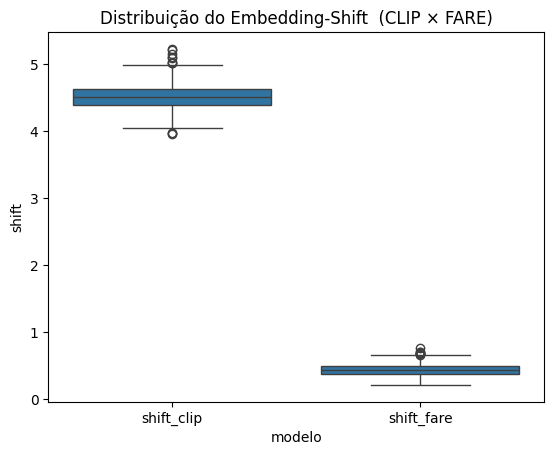

In [18]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon
import seaborn as sns, matplotlib.pyplot as plt
import re

   # caminho do arquivo

# ---- 1) Ler e extrair números ----------------------------------------------
pattern = re.compile(r"Diff CLIP:\s*([\d\.\-eE]+)\s*/\s*Diff FARE:\s*([\d\.\-eE]+)")
rows = []

with open(log_path, "r") as f:
    for line in f:
        matches = pattern.findall(line)   # devolve lista de tuplas
        for clip_val, fare_val in matches:
            rows.append({"shift_clip": float(clip_val),
                         "shift_fare": float(fare_val)})

df = pd.DataFrame(rows)
print("Total de entradas lidas:", len(df))

# ---- 2) Estatísticas --------------------------------------------------------
mean_clip, std_clip = df["shift_clip"].mean(), df["shift_clip"].std()
mean_fare, std_fare = df["shift_fare"].mean(), df["shift_fare"].std()

print(f"\nCLIP — média: {mean_clip:.4f},  std: {std_clip:.4f}")
print(f"FARE — média: {mean_fare:.4f}, std: {std_fare:.4f}")

# ---- 3) Testes de significância --------------------------------------------
t_stat, p_val  = ttest_rel(df["shift_clip"], df["shift_fare"])
w_stat, p_wilc = wilcoxon(df["shift_clip"], df["shift_fare"])

print(f"\nPaired t-test   p = {p_val:.3e}")
print(f"Wilcoxon signed-rank p = {p_wilc:.3e}")

# ---- 4) Visualização --------------------------------------------------------
sns.boxplot(data=df.melt(var_name="modelo", value_name="shift"),
            x="modelo", y="shift")
plt.title("Distribuição do Embedding-Shift  (CLIP × FARE)")
plt.show()

# ---- 5) Salvar CSV se desejar ----------------------------------------------
df.to_csv("/content/embedding_shift_train.csv", index=False)


In [19]:
save_dir = "/mnt/data"
os.makedirs(save_dir, exist_ok=True)        # cria /mnt/data se não existir
df.to_csv(os.path.join(save_dir, "embedding_shift_rival10.csv"), index=False)

df.to_csv("/mnt/data/embedding_shift_rival10.csv", index=False)


## Rodar o Teste

In [20]:

## Assinatura: class SimpleRival10Dataset(Dataset):
   # def __init__(self, root, split_json, wnid_json, split='train', transform=None):

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

root_dir      = "RIVAL10"
split_json    = "meta/novo_test_split.json"   # ou train_test_split_by_url.json
wnid_json     = "meta/wnid_to_class.json"

test_dataset = SimpleRival10Dataset(root_dir, split_json, wnid_json,
                                split="test", transform=transform)
print("Test samples:", len(test_dataset))

test_loader    = DataLoader(test_dataset, batch_size=8, shuffle=False)


Test samples: 10572


In [21]:
diffs_clip, diffs_fare = [], []

for images, labels in test_loader:
    images = images.to(device)

    with torch.no_grad(), torch.autocast("cuda", torch.float16):
        e_clip_clean  = clip_model.encode_image(images)
        e_fare_clean  = fare_model.encode_image(images)

    adv_images = fgsm_attack(clip_model, images, epsilon=2/255)

    with torch.no_grad(), torch.autocast("cuda", torch.float16):
        e_clip_adv = clip_model.encode_image(adv_images)
        e_fare_adv = fare_model.encode_image(adv_images)

    # L2 por amostra
    batch_clip = (e_clip_clean - e_clip_adv).norm(dim=1).cpu().tolist()
    batch_fare = (e_fare_clean - e_fare_adv).norm(dim=1).cpu().tolist()

    diffs_clip.extend(batch_clip)
    diffs_fare.extend(batch_fare)


In [22]:
import numpy as np, scipy.stats as st, pandas as pd

arr_clip = np.array(diffs_clip)
arr_fare = np.array(diffs_fare)

print(f"CLIP  – média {arr_clip.mean():.4f} | std {arr_clip.std():.4f}")
print(f"FARE  – média {arr_fare.mean():.4f} | std {arr_fare.std():.4f}")

t, p_t = st.ttest_rel(arr_clip, arr_fare)
w, p_w = st.wilcoxon(arr_clip, arr_fare)
print(f"paired t-test  p={p_t:.3e}")
print(f"Wilcoxon       p={p_w:.3e}")


CLIP  – média 4.4981 | std 1.0177
FARE  – média 0.4426 | std 0.4935
paired t-test  p=0.000e+00
Wilcoxon       p=0.000e+00


In [23]:
df = pd.DataFrame({"shift_clip": arr_clip, "shift_fare": arr_fare})
df.to_csv("/content/embedding_shift_test.csv", index=False)


<ipython-input-24-993284922>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr_clip, arr_fare], labels=["CLIP", "FARE"])


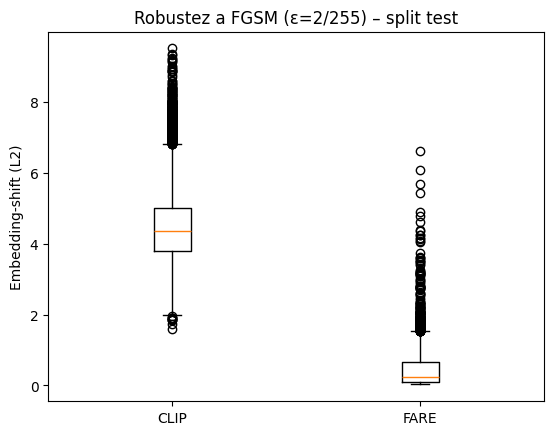

In [24]:
import matplotlib.pyplot as plt
plt.boxplot([arr_clip, arr_fare], labels=["CLIP", "FARE"])
plt.ylabel("Embedding-shift (L2)")
plt.title("Robustez a FGSM (ε=2/255) – split test")
plt.show()


In [25]:
import json, os

root = "RIVAL10"
with open(os.path.join(root, "meta/novo_train_split.json")) as f:
    train_imgs = json.load(f)["train"]
with open(os.path.join(root, "meta/novo_test_split.json")) as f:
    test_imgs  = json.load(f)["test"]

wnids = sorted({os.path.basename(p).split("_")[0] for p in train_imgs + test_imgs})
synset_to_idx = {wnid: i for i, wnid in enumerate(wnids)}

with open(os.path.join(root, "meta/synset_to_idx.json"), "w") as f:
    json.dump(synset_to_idx, f, indent=2)
print("Total classes =", len(synset_to_idx))


Total classes = 20


In [26]:
with open("RIVAL10/meta/wnid_to_class.json") as f:
    wn2name = json.load(f)

# --- para CLIP ---
token_clip  = clip.tokenize([f"a photo of a {c}" for c in wn2name]).to(device)
with torch.no_grad():
    class_emb_clip = clip_model.encode_text(token_clip)      # (10,512)
    class_emb_clip = class_emb_clip / class_emb_clip.norm(dim=-1, keepdim=True)

# --- para FARE ---
token_fare = clip.tokenize([f"a photo of a {c}" for c in wn2name]).to(device)
with torch.no_grad():
    class_emb_fare = fare_model.encode_text(token_fare)      # (10,768)
    class_emb_fare = class_emb_fare / class_emb_fare.norm(dim=-1, keepdim=True)

In [27]:
import torch

# Depois de terminar um grande loop ou uma etapa pesada:
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"

with open("RIVAL10/meta/wnid_to_class.json") as f:
    wn2name = json.load(f)

# Tokens de texto para zero-shot classifier
token_clip = clip.tokenize([f"a photo of a {c}" for c in wn2name]).to(device)
token_fare = clip.tokenize([f"a photo of a {c}" for c in wn2name]).to(device)

with torch.no_grad():
    class_emb_clip = clip_model.encode_text(token_clip)
    class_emb_clip = class_emb_clip / class_emb_clip.norm(dim=-1, keepdim=True)

    class_emb_fare = fare_model.encode_text(token_fare)
    class_emb_fare = class_emb_fare / class_emb_fare.norm(dim=-1, keepdim=True)

dataset_clean  = SimpleRival10Dataset(root="RIVAL10", split_json="meta/novo_test_split.json", wnid_json="meta/wnid_to_class.json", split="test", transform=transform)
dataset_robust = SimpleRival10Dataset(root="RIVAL10", split_json="meta/novo_test_split.json", wnid_json="meta/wnid_to_class.json", split="test", transform=transform)

test_loader_clean  = DataLoader(dataset_clean,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader_robust = DataLoader(dataset_robust, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# (3) Avaliação: rodar apenas com torch.no_grad() e batch_size=8
correct_clean_clip = correct_adv_clip = total_clip = 0
correct_clean_fare = correct_adv_fare = total_fare = 0

In [28]:
# ------------------- LOOP 1 – CLIP ----------------------------
correct_clean_clip = correct_adv_clip = total_clip = 0

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    # --- clean ---
    with torch.no_grad():
        emb = clip_model.encode_image(images)          # (N,512)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        preds = (emb @ class_emb_clip.T).argmax(1)     # (N,)
        correct_clean_clip += (preds == labels).sum().item()

    # --- adversarial ---
    adv_images = fgsm_attack(clip_model, images, 2/255)
    with torch.no_grad():
        emb_adv = clip_model.encode_image(adv_images)
        emb_adv = emb_adv / emb_adv.norm(dim=-1, keepdim=True)
        preds_adv = (emb_adv @ class_emb_clip.T).argmax(1)
        correct_adv_clip += (preds_adv == labels).sum().item()

    total_clip += labels.size(0)

# ------------------- LOOP 2 – FARE ----------------------------
correct_clean_fare = correct_adv_fare = total_fare = 0

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    # --- clean ---
    with torch.no_grad():
        emb = fare_model.encode_image(images)          # (N,768)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        preds = (emb @ class_emb_fare.T).argmax(1)     # (N,)
        correct_clean_fare += (preds == labels).sum().item()

    # --- adversarial ---
    adv_images = fgsm_attack(fare_model, images, 2/255)
    with torch.no_grad():
        emb_adv = fare_model.encode_image(adv_images)
        emb_adv = emb_adv / emb_adv.norm(dim=-1, keepdim=True)
        preds_adv = (emb_adv @ class_emb_fare.T).argmax(1)   # <-- aqui mudou
        correct_adv_fare += (preds_adv == labels).sum().item()

    total_fare += labels.size(0)

# ------------------- porcentagens -----------------------------
acc_clip_clean = 100 * correct_clean_clip / total_clip
acc_clip_adv   = 100 * correct_adv_clip   / total_clip
acc_fare_clean = 100 * correct_clean_fare / total_fare
acc_fare_adv   = 100 * correct_adv_fare   / total_fare

print(f"CLIP – clean {acc_clip_clean:.2f}%   adv {acc_clip_adv:.2f}%")
print(f"FARE – clean {acc_fare_clean:.2f}%   adv {acc_fare_adv:.2f}%")

CLIP – clean 0.03%   adv 0.02%
FARE – clean 0.00%   adv 0.00%


,model,clean (%),adv (%)
0,CLIP,0.028377,0.018918
1,FARE,0.000000,0.000000


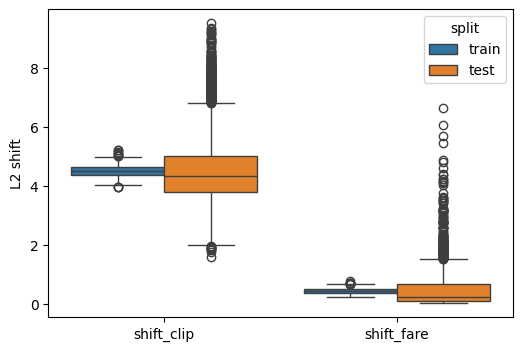

In [29]:
# a) Boxplot final (embedding-shift)
import seaborn as sns, matplotlib.pyplot as plt, pandas as pd
df = pd.concat([
        pd.read_csv("embedding_shift_train.csv").assign(split="train"),
        pd.read_csv("embedding_shift_test.csv").assign(split="test")
     ])
plt.figure(figsize=(6,4))
sns.boxplot(data=df.melt(id_vars="split",
                         value_vars=["shift_clip","shift_fare"]),
            x="variable", y="value", hue="split")
plt.ylabel("L2 shift"); plt.xlabel(""); plt.savefig("fig_shift_boxplot.pdf")

# b) Tabela de acurácia
acc_table = pd.DataFrame({
    "model"     : ["CLIP", "FARE"],
    "clean (%)" : [acc_clip_clean, acc_fare_clean],
    "adv (%)"   : [acc_clip_adv,  acc_fare_adv],
})
acc_table.to_csv("accuracy_table.csv", index=False)
acc_table


## Avaliação de Imagens do Teste

In [30]:
import torch
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def show_examples(
    model_clean,            # ex: clip_model (já em device)
    model_robust,           # ex: fare_model (já em device)
    preprocess_clean,       # Compose do CLIP: [Resize, ToTensor, Normalize]
    preprocess_robust,      # Compose do FARE: [Resize, ToTensor, Normalize]
    test_loader_clean,      # DataLoader com imagens normalizadas em preprocess_clean
    test_loader_robust,     # DataLoader com imagens normalizadas em preprocess_robust
    device="cuda",
    n=4,
    epsilon=8/255
):
    """
    Plota um grid com n colunas:
      - top row: n imagens 'clean'
      - bottom row: mesmas n imagens 'adv' (perturbadas por FGSM)
    Faz isso duas vezes: uma para CLIP (à esquerda) e outra para FARE (à direita).
    """

    # 1) Extraímos mean/std de cada Normalize dentro dos Compose:
    from torchvision import transforms

    # -- Normalize do CLIP:
    normalize_c = None
    for t in preprocess_clean.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_c = t
            break
    assert normalize_c is not None, "preprocess_clean não contém Normalize()"
    mean_c = torch.tensor(normalize_c.mean).view(3,1,1).to(device)
    std_c  = torch.tensor(normalize_c.std).view(3,1,1).to(device)

    # -- Normalize do FARE:
    normalize_r = None
    for t in preprocess_robust.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_r = t
            break
    assert normalize_r is not None, "preprocess_robust não contém Normalize()"
    mean_r = torch.tensor(normalize_r.mean).view(3,1,1).to(device)
    std_r  = torch.tensor(normalize_r.std).view(3,1,1).to(device)

    # 2) Funções de “desnormalização” (para exibir no matplotlib no intervalo [0,1]):
    def denormalize_clean(x_norm: torch.Tensor) -> torch.Tensor:
        # x_norm: tensor [N,3,H,W] normalizado em preprocess_clean
        return (x_norm * std_c + mean_c).clamp(0,1)

    def denormalize_robust(x_norm: torch.Tensor) -> torch.Tensor:
        # x_norm: tensor [N,3,H,W] normalizado em preprocess_robust
        return (x_norm * std_r + mean_r).clamp(0,1)

    # 3) Pegamos “n” imagens de cada loader:
    imgs_clean, _ = next(iter(test_loader_clean))   # imgs_clean tem shape [B,3,224,224]
    imgs_robust, _ = next(iter(test_loader_robust)) # imgs_robust tem shape [B,3,224,224]

    imgs_clean = imgs_clean[:n].to(device)     # seleciona apenas as primeiras n
    imgs_robust = imgs_robust[:n].to(device)

    # 4) Gera as imagens adversariais (FGSM) – lembrando de normalizar e perturbá-las:
    #    Note que a fgsm_attack() deve receber o modelo, as imagens normalizadas e epsilon:
    adv_clean  = fgsm_attack(model_clean,  imgs_clean,  epsilon)
    adv_robust = fgsm_attack(model_robust, imgs_robust, epsilon)

    # 5) Agora montamos 2 grids: um para CLIP, outro para FARE:
    #    Cada grid terá 2 linhas (top=clean, bot=adv) e n colunas.
    #    Vamos concatenar imgs_clean + adv_clean ao longo da dimensão 0:
    grid_clip = make_grid(torch.cat([ imgs_clean.cpu(), adv_clean.cpu() ], dim=0),
                         nrow=n, padding=2)
    grid_fare = make_grid(torch.cat([ imgs_robust.cpu(), adv_robust.cpu() ], dim=0),
                         nrow=n, padding=2)

    # 6) Desfazemos a normalização para exibição:
    grid_clip = denormalize_clean(grid_clip.to(device))
    grid_fare = denormalize_robust(grid_fare.to(device))

    # 7) Plotando lado a lado:
    fig, axes = plt.subplots(1, 2, figsize=(n*2.5, 5))
    # CLIP plot
    axes[0].imshow(grid_clip.detach().cpu().permute(1,2,0))
    axes[0].set_title("CLIP: clean (top) × adv (bottom)")
    axes[0].axis("off")
    # FARE plot
    axes[1].imshow(grid_fare.detach().cpu().permute(1,2,0))
    axes[1].set_title("FARE: clean (top) × adv (bottom)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [31]:
# 1) Definimos transformações via create_model_and_transforms(...)
clip_model, preprocess_clip = clip.load("ViT-B/32", device=device)
fare_model, preprocess_fare, fare_post = create_model_and_transforms("hf-hub:chs20/fare2-clip")

In [32]:
# 2) Carregamos os datasets (mesmo JSON “split” para ambos, mas com transformações diferentes):
train_split_json = "meta/novo_test_split.json"
wnid_json       = "meta/wnid_to_class.json"

dataset_clean = SimpleRival10Dataset(
    root       = "RIVAL10",
    split_json = train_split_json,
    wnid_json  = wnid_json,
    split      = "test",
    transform  = preprocess_clip     # NORMALIZE do CLIP
)
test_loader_clean = DataLoader(dataset_clean, batch_size=32, shuffle=False)

dataset_robust = SimpleRival10Dataset(
    root       = "RIVAL10",
    split_json = train_split_json,
    wnid_json  = wnid_json,
    split      = "test",
    transform  = preprocess_fare     # NORMALIZE do FARE
)
test_loader_robust = DataLoader(dataset_robust, batch_size=32, shuffle=False)


In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model  = clip_model.to(device).eval()
fare_model  = fare_model.to(device).eval()


In [34]:

# 3) Teste rápido para ver se ambos retornam batches válidos:
batch_c = next(iter(test_loader_clean))
print("Clean batch imgs:", batch_c[0].shape, "labels:", batch_c[1].shape)
batch_r = next(iter(test_loader_robust))
print("Robust batch imgs:", batch_r[0].shape, "labels:", batch_r[1].shape)
# Ambos devem exibir algo como (32,3,224,224) e (32,) em CPU.


Clean batch imgs: torch.Size([32, 3, 224, 224]) labels: torch.Size([32])
Robust batch imgs: torch.Size([32, 3, 224, 224]) labels: torch.Size([32])


In [35]:
preprocess_clean = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

In [36]:
from torchvision import transforms

# supondo que preprocess_clean já foi definido como acima
# 1. encontre o objeto Normalize:
normalize_c = None
for t in preprocess_clean.transforms:        # percorre cada etapa interna
    if isinstance(t, transforms.Normalize):
        normalize_c = t
        break

assert normalize_c is not None, "Nenhum Normalize() encontrado em preprocess_clean"

# agora normalize_c é justamente aquela instância de Normalize(mean=..., std=...)
mean_c = torch.tensor(normalize_c.mean).view(3,1,1).to(device)
std_c  = torch.tensor(normalize_c.std).view(3,1,1).to(device)

In [37]:
# 1) Abra o wnid_to_class.json
with open("RIVAL10/meta/wnid_to_class.json", "r") as f:
    wnid_to_class = json.load(f)
# Exemplo: wnid_to_class == { "n01440764": "tigre", "n01443537": "papagaio", ... }

# 2) Extraia e ordene a lista de WNIDs
all_wnids = sorted(wnid_to_class.keys())
# Por exemplo: ["n01440764", "n01443537", "n01484850", ...]

# 3) Crie wnid_to_idx e idx_to_name
wnid_to_idx = {}
idx_to_name = []   # lista onde idx_to_name[i] = nome da i‐ésima classe

for idx, wnid in enumerate(all_wnids):
    wnid_to_idx[wnid] = idx
    idx_to_name.append(wnid_to_class[wnid])

# Agora:
#   wnid_to_idx["n01440764"] = 0
#   wnid_to_idx["n01443537"] = 1
#   ...
#
#   idx_to_name[0] == "tigre"
#   idx_to_name[1] == "papagaio"
#   ...

# (Opcional) Se quiser salvar esse mapeamento em disco:
with open("RIVAL10/meta/wnid_to_idx.json", "w") as f:
     json.dump(wnid_to_idx, f, indent=2)


In [38]:
import json

# Caminhos dos seus arquivos (no Colab ou local):
wnid_to_class_path = "RIVAL10/meta/wnid_to_class.json"
wnid_to_idx_path   = "RIVAL10/meta/wnid_to_idx.json"

# 1.a) WNID → Nome da classe (string legível)
with open(wnid_to_class_path, "r") as f:
    wnid_to_class = json.load(f)
# ex: wnid_to_class["n01440764"] == "tigre"

# 1.b) WNID → Índice inteiro
with open(wnid_to_idx_path, "r") as f:
    wnid_to_idx = json.load(f)
# ex: wnid_to_idx["n01440764"] == 0


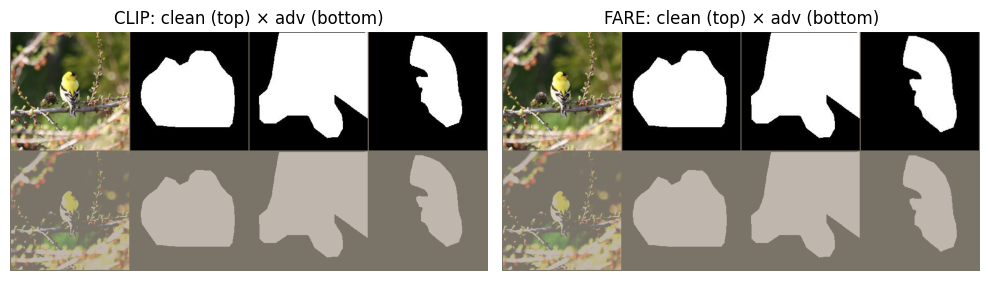

In [39]:
#show_examples(clip_model,fare_model,preprocess,fare_pre, test_loader, 'cuda')

# 4) Finalmente invoque show_examples
show_examples(
    clip_model,
    fare_model,
    preprocess_clip,
    preprocess_fare,
    test_loader_clean,
    test_loader_robust,
    device="cuda",
    n=4,
    epsilon=8/255
)

In [40]:
import torch.nn.functional as F

def show_diff_heatmap(model, n=4):
    """
    Exibe, para as n primeiras imagens:
      - Coluna 1: Clean
      - Coluna 2: Adv
      - Coluna 3: Heatmap da diferença
    """
    imgs, advs, heatmaps = [], [], []
    for images, _ in test_loader:
        images = images[:n].to(device)
        adv = fgsm_attack(model, images, epsilon=2/255).to(device)

        imgs.append(images.cpu())
        advs.append(adv.cpu())

        # 1) Diferença absoluta
        diff = torch.abs(adv - images)  # (n, 3, H, W)
        # 2) Converta para grayscale (média nos 3 canais)
        diff_gray = diff.mean(dim=1, keepdim=True)  # (n, 1, H, W)
        # 3) Normalize entre 0 e 1
        diff_gray = (diff_gray - diff_gray.min()) / (diff_gray.max() - diff_gray.min() + 1e-8)
        heatmaps.append(diff_gray.cpu())
        break

    imgs   = torch.cat(imgs, dim=0)
    advs   = torch.cat(advs, dim=0)
    heat   = torch.cat(heatmaps, dim=0)  # (n, 1, H, W)

    # Para cada imagem, vamos plotar lado a lado clean / adv / heatmap com colormap
    for i in range(n):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))

        # Imagem clean (desnormalize se tiver normalização)
        img = imgs[i]
        # Se você normalizou com mean/std, é necessário desnormalizar antes:
        # Exemplo (para ImageNet mean/std):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_disp = img * std + mean   # bring back to [0,1]
        img_disp = torch.clamp(img_disp, 0, 1)
        axs[0].imshow(img_disp.permute(1,2,0))
        axs[0].set_title("Clean")
        axs[0].axis('off')

        # Imagem adversarial
        adv_img = advs[i]
        adv_disp = adv_img * std + mean
        adv_disp = torch.clamp(adv_disp, 0, 1)
        axs[1].imshow(adv_disp.permute(1,2,0))
        axs[1].set_title("Adv")
        axs[1].axis('off')

        # Heatmap da diferença (colormap “jet”)
        hm = heat[i].squeeze(0).numpy()  # shape (H, W)
        axs[2].imshow(hm, cmap='jet')
        axs[2].set_title("Heatmap diff")
        axs[2].axis('off')

        plt.suptitle(f"Exemplo {i+1}")
        plt.tight_layout()
        plt.show()


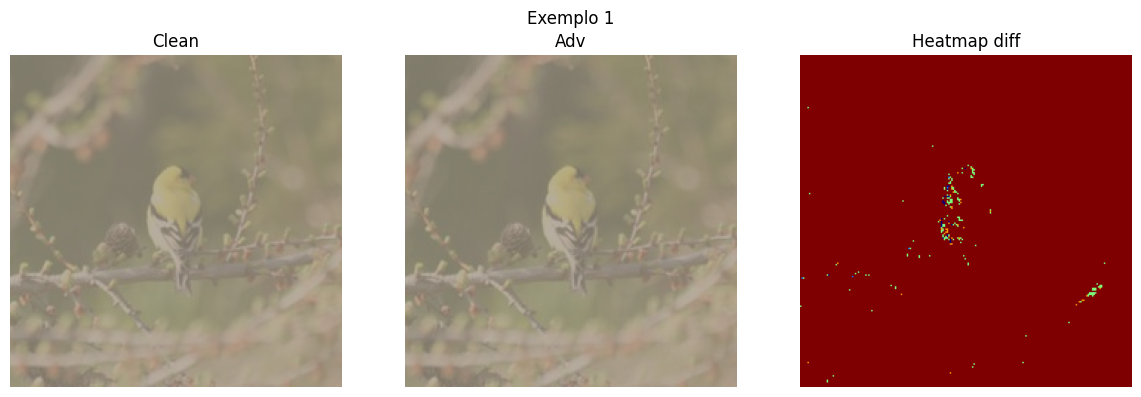

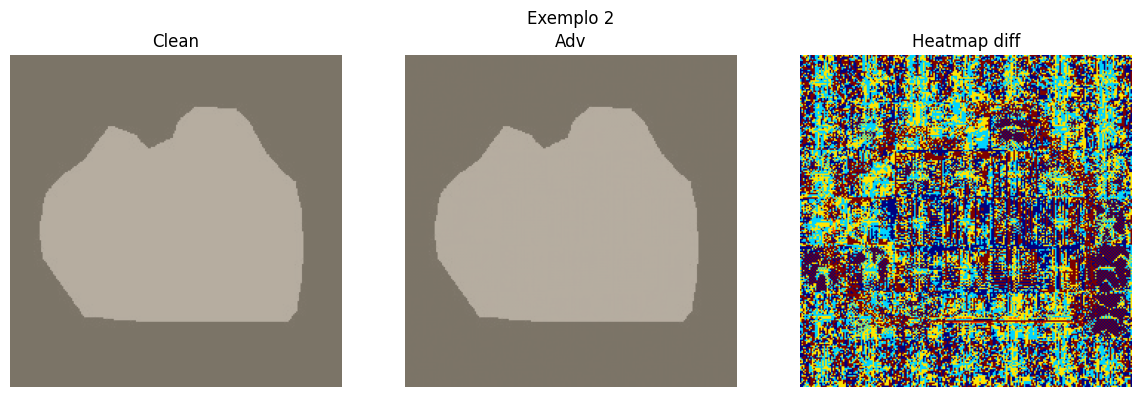

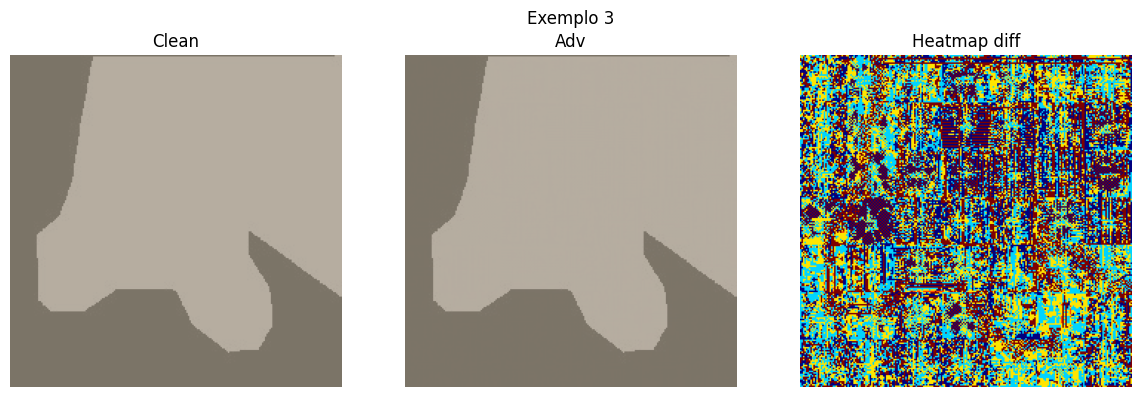

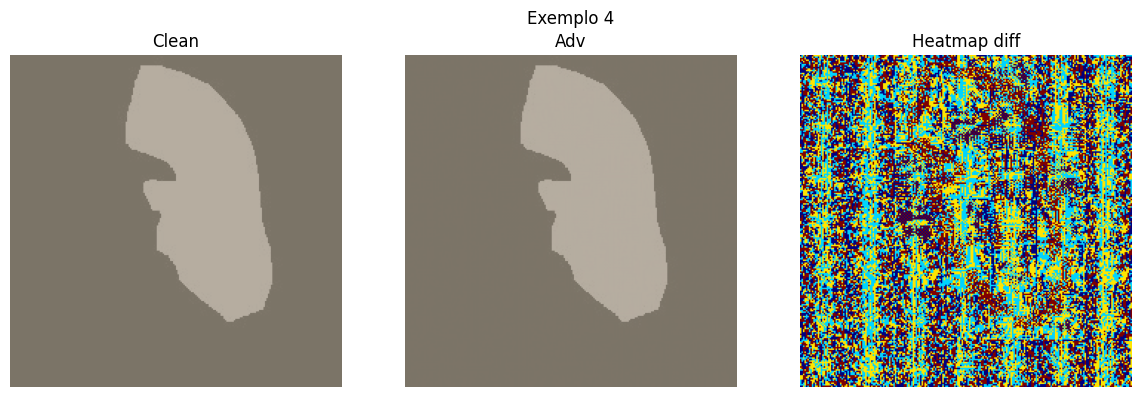

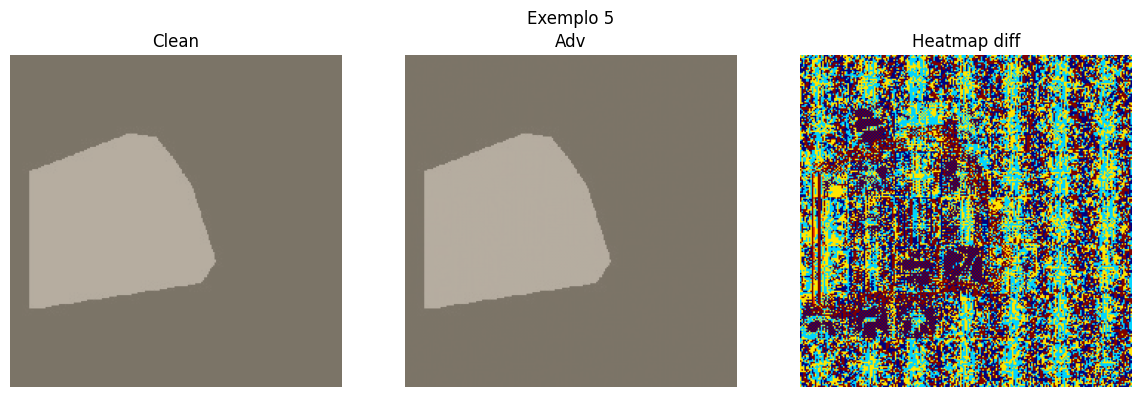

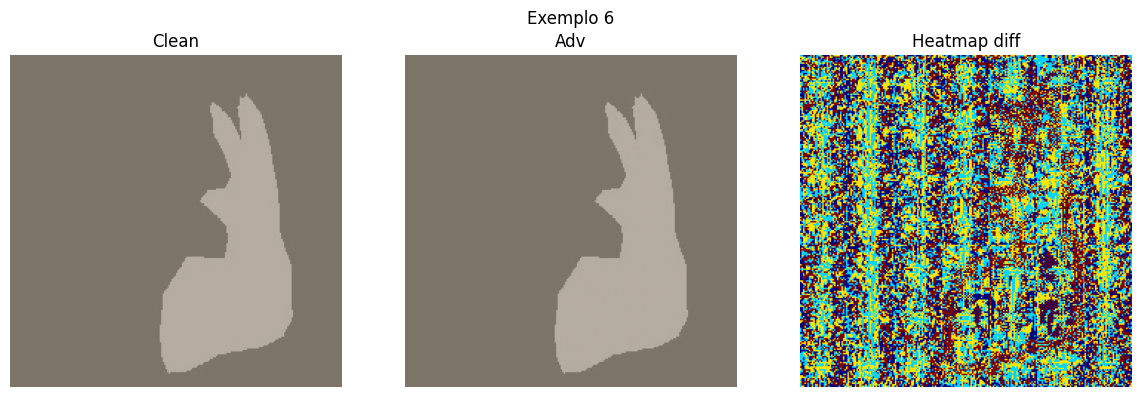

In [41]:
# Supondo que as funções já estejam definidas no seu notebook:
#   - show_diff_heatmap(model, n=4)
#   - fgsm_attack(model, images, eps)
#   - test_loader, device, classes e clip_model

# =====================================
# 2) Chamada da função
# =====================================
# Aqui vamos exibir 4 exemplos (n=4), gerando um heatmap colorido da diferença:
show_diff_heatmap(
    model=clip_model,
    n=6
)

In [42]:
import cv2
import numpy as np

def show_edge_overlay(model, n=4):
    """
    Para as n primeiras imagens:
      - Converte cada tensor para numpy uint8
      - Aplica filtro Sobel em grayscale para extrair bordas
      - Sobrepõe as bordas adv (vermelho) sobre as bordas originais (verde)
    """
    imgs, advs = [], []
    for images, _ in test_loader:
        images = images[:n].to(device)
        adv = fgsm_attack(model, images, epsilon=2/255).to(device)

        imgs.append(images.cpu())
        advs.append(adv.cpu())
        break

    imgs = torch.cat(imgs, dim=0)
    advs = torch.cat(advs, dim=0)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    for i in range(n):
        # 1) Desnormalize e converta para formato OpenCV: HxWxc em uint8
        img = imgs[i] * std + mean
        adv = advs[i] * std + mean
        img_np = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)
        adv_np = (adv.permute(1,2,0).numpy() * 255).astype(np.uint8)

        # 2) Converta para grayscale
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        adv_gray = cv2.cvtColor(adv_np, cv2.COLOR_RGB2GRAY)

        # 3) Detecte bordas (Sobel ou Canny)
        edges_img = cv2.Canny(img_gray, 50, 150)
        edges_adv = cv2.Canny(adv_gray, 50, 150)

        # 4) Crie uma imagem colorida para sobrepor:
        #    - verde = bordas do original
        #    - vermelho = bordas do adv
        overlay = np.zeros_like(img_np)
        overlay[edges_img != 0] = [0, 255, 0]  # verde
        overlay[edges_adv != 0] = [255, 0, 0]   # vermelho

        # 5) Combine overlay com a imagem original (com alpha menor, ex.: 0.6)
        combined = cv2.addWeighted(img_np, 0.6, overlay, 0.4, 0)

        # 6) Exiba
        plt.figure(figsize=(6, 6))
        plt.imshow(combined)
        plt.axis('off')
        plt.title(f"Exemplo {i+1}: Bordas (verde=clean, vermelho=adv)")
        plt.show()


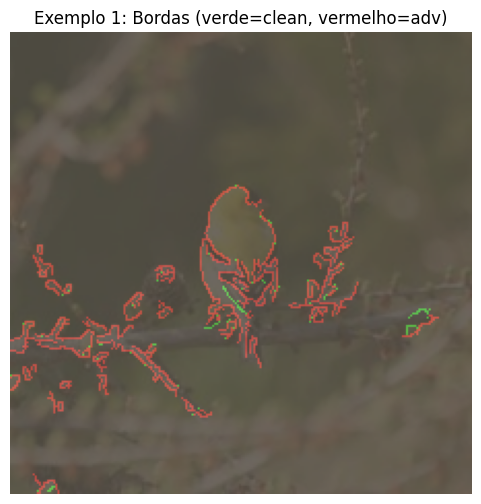

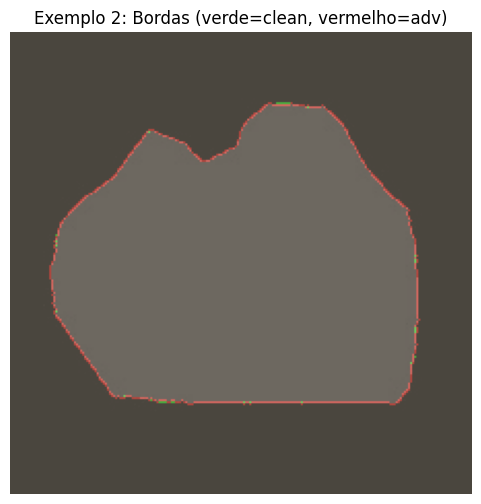

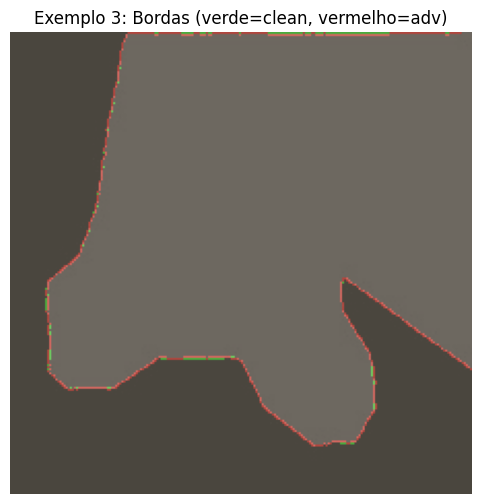

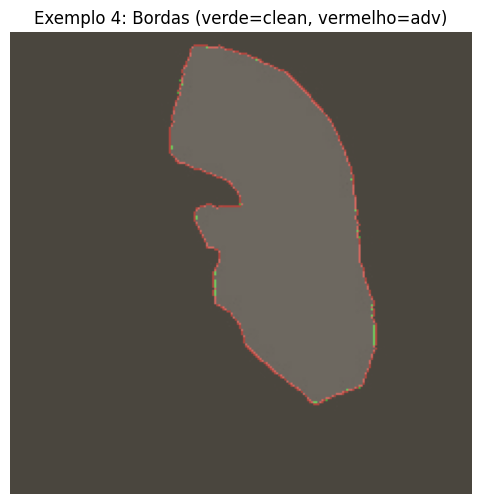

In [43]:
show_edge_overlay(fare_model, 4)

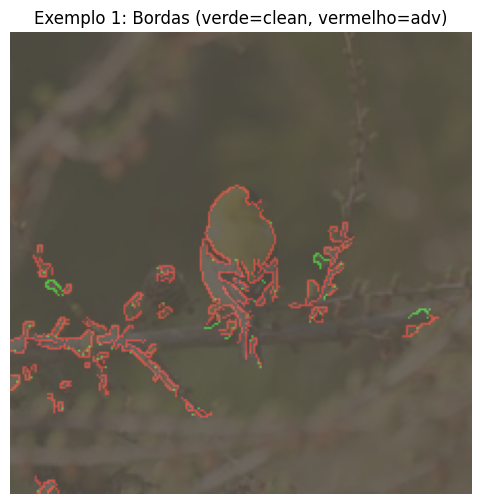

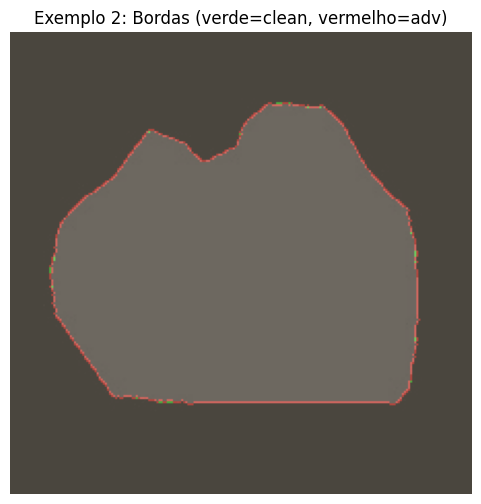

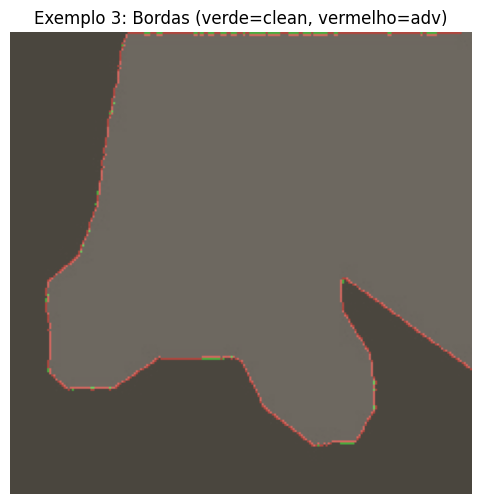

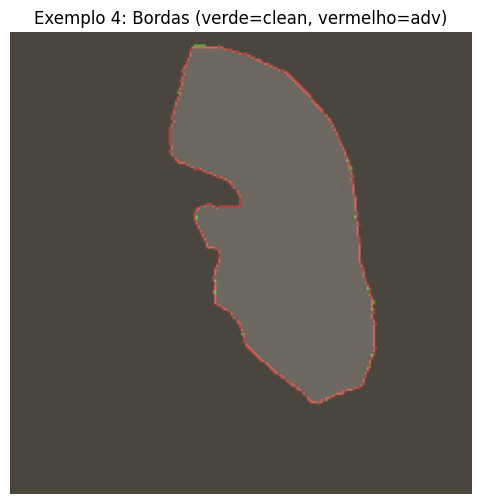

In [44]:
show_edge_overlay(clip_model, 4)

In [45]:
import torch.nn.functional as F

def show_preds_vs_adv(model, n=4):
    """
    Exibe as n primeiras imagens com suas previsões (rótulo e probabilidade)
    antes e depois do ataque adversarial.
    """
    model.eval()
    imgs, advs = [], []
    labels_list = []
    for images, labels in test_loader:
        images = images[:n].to(device)
        labels = labels[:n].to(device)
        adv = fgsm_attack(model, images, epsilon=2/255).to(device)

        imgs.append(images.cpu())
        advs.append(adv.cpu())
        labels_list.append(labels.cpu())
        break

    imgs   = torch.cat(imgs, dim=0)
    advs   = torch.cat(advs, dim=0)
    labels = torch.cat(labels_list, dim=0)
    softmax = torch.nn.Softmax(dim=1)

    for i in range(n):
        img = imgs[i].unsqueeze(0).to(device)
        adv = advs[i].unsqueeze(0).to(device)

        # Predição clean
        with torch.no_grad():
            out_clean = model(img)
            probs_clean, preds_clean = torch.max(softmax(out_clean), dim=1)
        # Predição adv
        with torch.no_grad():
            out_adv = model(adv)
            probs_adv, preds_adv = torch.max(softmax(out_adv), dim=1)

        # Desnormalize para exibir:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

        img_disp = img.cpu().squeeze(0) * std + mean
        img_disp = torch.clamp(img_disp, 0, 1)

        adv_disp = adv.cpu().squeeze(0) * std + mean
        adv_disp = torch.clamp(adv_disp, 0, 1)

        fig, axs = plt.subplots(1, 2, figsize=(8, 4))

        axs[0].imshow(img_disp.permute(1,2,0))
        axs[0].set_title(f"Clean:\nPred = {classes[preds_clean]}\nConf = {probs_clean.item():.2f}")
        axs[0].axis('off')

        axs[1].imshow(adv_disp.permute(1,2,0))
        axs[1].set_title(f"Adv:\nPred = {classes[preds_adv]}\nConf = {probs_adv.item():.2f}")
        axs[1].axis('off')

        plt.suptitle(f"Exemplo {i+1} (Label real = {classes[labels[i]]})")
        plt.tight_layout()
        plt.show()


In [ ]:
with open("RIVAL10/meta/wnid_to_class.json", "r") as f:
    wnid_to_class = json.load(f)

all_wnids = sorted(wnid_to_class.keys())

wnid_to_idx = {}
idx_to_name = []
for idx, wnid in enumerate(all_wnids):
    wnid_to_idx[wnid] = idx
    idx_to_name.append(wnid_to_class[wnid])

# show_preds_vs_adv(
#     model      = fare_model,
#     n          = 4     # quantos exemplos quer mostrar
# )

In [47]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np

def grad_cam(model, inp, target_class, class_emb, device="cuda"):
    """
    Grad-CAM para Vision Transformer (ViT) (por exemplo, CLIP-ViT ou FARE-ViT).
    Adicionamos aqui um 'guard' que devolve um mapa de zeros caso,
    por algum motivo, não haja tokens de patch capturados pelo hook.

    Parâmetros:
      • model        : CLIP/FARE em modo .eval(), já movido para `device`.
      • inp          : tensor [1,3,224,224] normalizado.
      • target_class : índice da classe a explicar.
      • class_emb    : tensor [num_classes, D] (onde D=512 ou 768),
                       já normalizado (embedding de texto das classes).
      • device       : "cuda" ou "cpu".
    Retorna:
      • heatmap [224×224], float em [0,1].
    """

    model.eval()
    activations = None
    gradients   = None

    # 1) Tentar localizar o último bloco Transformer (ResBlock) no ViT:
    #    Caso seu modelo seja exatamente CLIP-ViT ou FARE-ViT, este caminho funciona:
    try:
        last_block = model.visual.transformer.resblocks[-1]
    except:
        # Se não existir esse atributo, devolvemos mapa zero de uma vez:
        return np.zeros((224, 224), dtype=np.float32)

    # 2) Hooks para capturar ativações e gradientes
    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.detach()

    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0].detach()

    f_handle = last_block.register_forward_hook(forward_hook)
    b_handle = last_block.register_backward_hook(backward_hook)

    # 3) Forward → embedding → logits → score
    emb = model.encode_image(inp.to(device))              # [1, D]
    emb = emb / emb.norm(dim=-1, keepdim=True)
    logits = emb @ class_emb.T                             # [1, num_classes]
    score  = logits[0, target_class]                       # escalar para a classe alvo

    # 4) Backward → preencher `gradients`
    model.zero_grad()
    score.backward(retain_graph=True)

    # 5) Verificar se o hook gravou algo válido:
    if (activations is None) or (gradients is None):
        # Se não houve captura (activations nunca mudou de None),
        # devolvemos um mapa todo zero:
        f_handle.remove()
        b_handle.remove()
        return np.zeros((224, 224), dtype=np.float32)

    # 6) Extrair só os patches (descarta token CLS em índice 0)
    #    Esperamos shape [1, seq_len, width]. Se seq_len==1, não há patch.
    if activations.size(1) <= 1:
        # Não há nem um token de patch. Retorna mapa zero:
        f_handle.remove()
        b_handle.remove()
        return np.zeros((224, 224), dtype=np.float32)

    acts = activations[0, 1:, :].clone()   # [num_patches, width]
    grads= gradients[0, 1:, :].clone()     # [num_patches, width]

    # 7) Cálculo de α_k = média dos gradientes no (num_patches × width)
    weights = grads.mean(dim=0)            # [width]

    # 8) Combinação linear: soma_k α_k * A[p,k] para cada patch p
    cam_patch = (acts * weights.unsqueeze(0)).sum(dim=1)  # [num_patches]

    # 9) ReLU e normalização em [0,1]
    cam_patch = torch.relu(cam_patch)
    if cam_patch.numel() == 0:
        # Mesmo caso redundante: se algo deu errado e não há elementos
        f_handle.remove()
        b_handle.remove()
        return np.zeros((224, 224), dtype=np.float32)

    cam_patch = (cam_patch - cam_patch.min()) / (cam_patch.max() - cam_patch.min() + 1e-6)

    # 10) Reconstrói grid quadrado de patches (por ex. 16×16 para ViT-L/14)
    num_patches = cam_patch.shape[0]
    grid_size = int(num_patches ** 0.5)
    if grid_size * grid_size != num_patches:
        # Não forma um quadrado exato → fallback para mapa zero:
        f_handle.remove()
        b_handle.remove()
        return np.zeros((224, 224), dtype=np.float32)

    cam_grid = cam_patch.reshape(grid_size, grid_size).cpu().numpy()  # [H',W']

    # 11) Redimensiona para 224×224
    heatmap = cv2.resize(cam_grid, (224,224), interpolation=cv2.INTER_CUBIC)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-6)

    # 12) Remove hooks e devolve
    f_handle.remove()
    b_handle.remove()
    return heatmap  # float32 [224,224] em [0,1]


In [60]:
def show_gradcam_comparison(model, class_emb, classes, test_loader, n=4, epsilon=2/255, device="cuda"):
    model.eval()

    # Defina mean/std (ajuste se não for ImageNet defaults)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

    # Checar se é ViT ou ResNet (acessível em model.visual)
    is_vit = hasattr(model.visual, "transformer") and hasattr(model.visual.transformer, "resblocks")
    # Se is_vit==False, supomos que seja ResNet

    # Pega n primeiras imagens
    for images, labels in test_loader:
        images = images[:n].to(device)
        adv    = fgsm_attack(model, images, epsilon=epsilon).to(device)
        break

    images_cpu = images.cpu()
    adv_cpu    = adv.cpu()
    labels_cpu = labels[:n].cpu()

    for i in range(n):
        img_norm = images_cpu[i]
        adv_norm = adv_cpu[i]

        # Desnormalize
        img_unnorm = img_norm.to(device) * std + mean
        adv_unnorm = adv_norm.to(device) * std + mean
        img_np = (img_unnorm.cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)
        adv_np = (adv_unnorm.cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)

        inp_clean = img_norm.unsqueeze(0).to(device)
        inp_adv   = adv_norm.unsqueeze(0).to(device)

        # 1) Predição clean
        with torch.no_grad():
            emb_clean    = model.encode_image(inp_clean)
            emb_clean    = emb_clean / emb_clean.norm(dim=-1, keepdim=True)
            logits_clean = emb_clean @ class_emb.T
            _, pred_orig = torch.max(logits_clean, dim=1)

        # 2) Predição adversarial
        with torch.no_grad():
            emb_adv      = model.encode_image(inp_adv)
            emb_adv      = emb_adv / emb_adv.norm(dim=-1, keepdim=True)
            logits_adv   = emb_adv @ class_emb.T
            _, pred_adv  = torch.max(logits_adv, dim=1)

        # 3) Grad-CAM (chama a função certa)
        if is_vit:
            cam_orig = grad_cam(model, inp_clean, pred_orig.item(), class_emb, device=device)
            cam_adv  = grad_cam(model, inp_adv,   pred_adv.item(),   class_emb, device=device)
        else:
            cam_orig = grad_cam_resnet(model, inp_clean, pred_orig.item(), class_emb, device=device)
            cam_adv  = grad_cam_resnet(model, inp_adv,   pred_adv.item(),   class_emb, device=device)


        # 4) Constrói heatmaps coloridos e sobrepõe
        heatmap_orig = cv2.applyColorMap((cam_orig*255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_adv  = cv2.applyColorMap((cam_adv*255).astype(np.uint8),  cv2.COLORMAP_JET)

        overlay_orig = cv2.addWeighted(img_np, 0.4, heatmap_orig, 0.6, 0)
        overlay_adv  = cv2.addWeighted(adv_np, 0.4, heatmap_adv,  0.6, 0)

        # 5) Exibir
        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))

        ax0.imshow(cv2.cvtColor(overlay_orig, cv2.COLOR_BGR2RGB))
        ax0.set_title(f"Grad-CAM (Clean)  → {classes[pred_orig.item()]}")
        ax0.axis('off')

        ax1.imshow(cv2.cvtColor(overlay_adv, cv2.COLOR_BGR2RGB))
        ax1.set_title(f"Grad-CAM (Adv)    → {classes[pred_adv.item()]}")
        ax1.axis('off')

        plt.suptitle(f"Exemplo {i+1} – Label real = {classes[labels_cpu[i].item()]}")
        plt.tight_layout()
        plt.show()


In [49]:
# Teste rápido para ver se o submódulo existe
hasattr(clip_model.visual, "transformer") and hasattr(clip_model.visual.transformer, "resblocks")


True

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


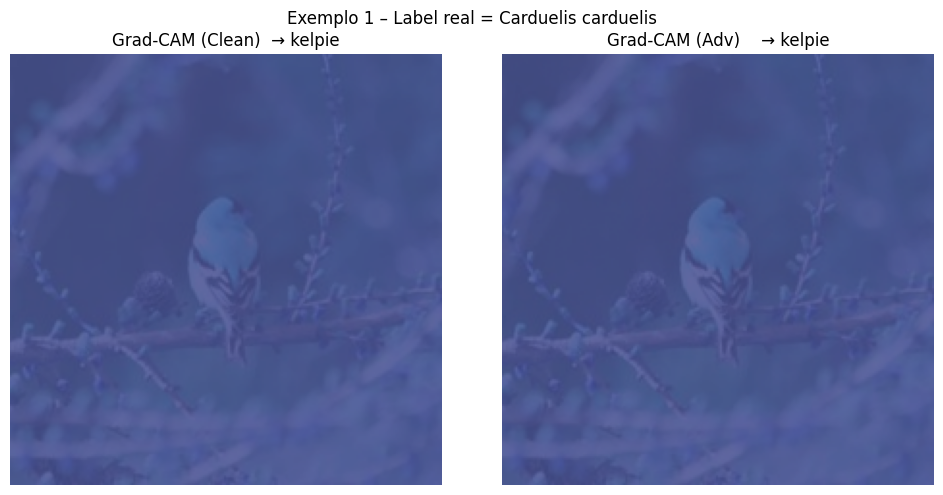

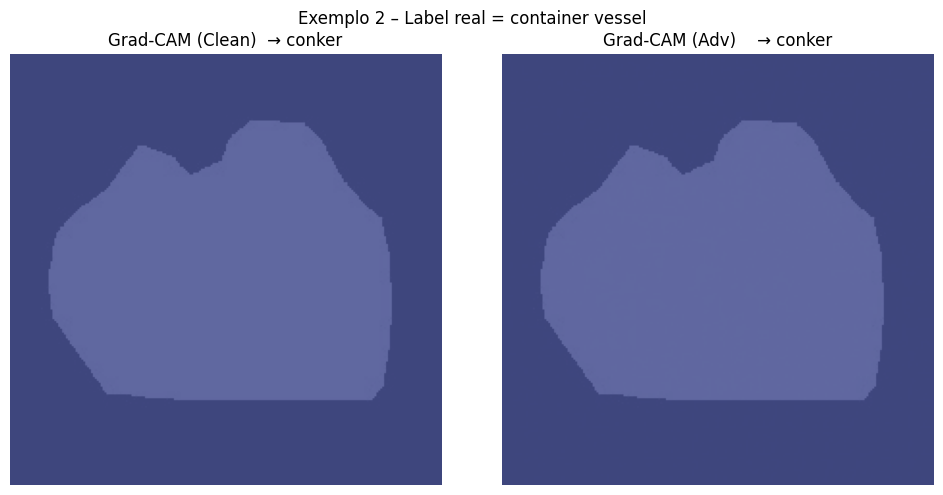

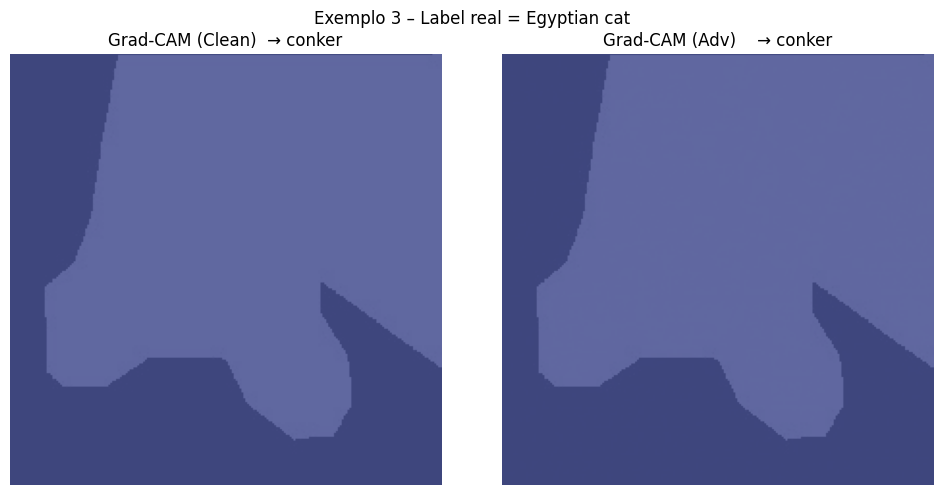

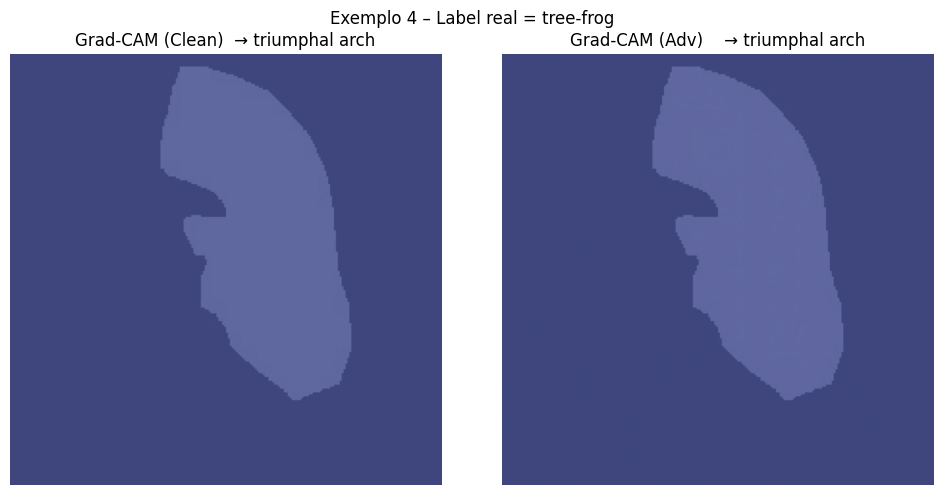

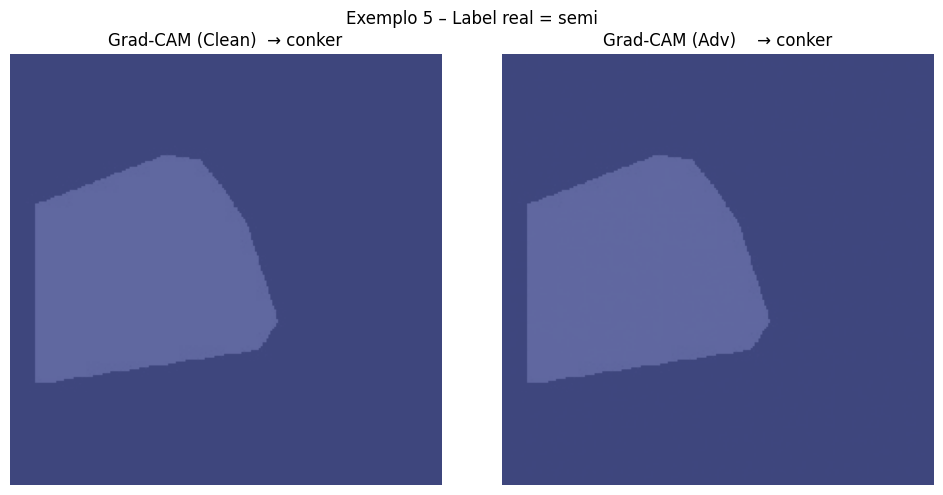

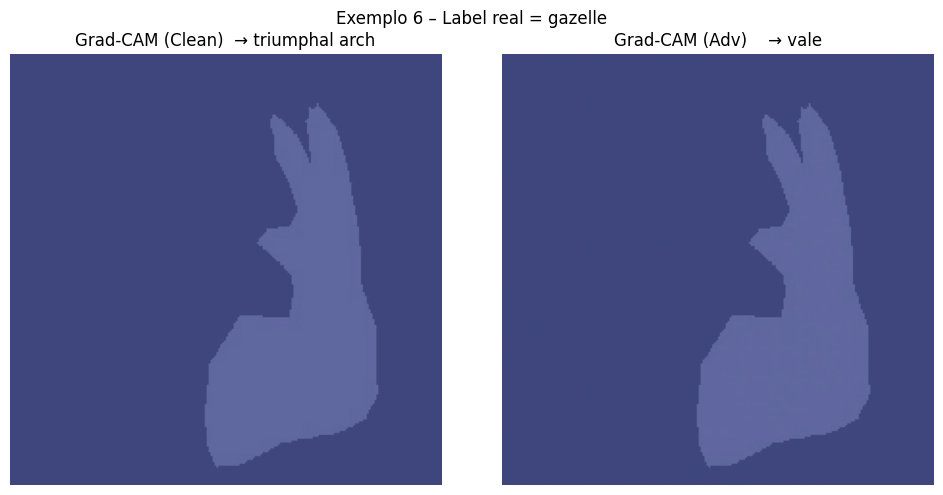

In [50]:
show_gradcam_comparison(
    model      = fare_model,
    class_emb  = class_emb_fare,
    classes    = idx_to_name,    # lista index→nome, criada a partir de wnid_to_class.json
    test_loader= test_loader,
    n          = 6,             # quantos exemplos quer visualizar
    epsilon    = 2/255,
    device     = "cuda"
)

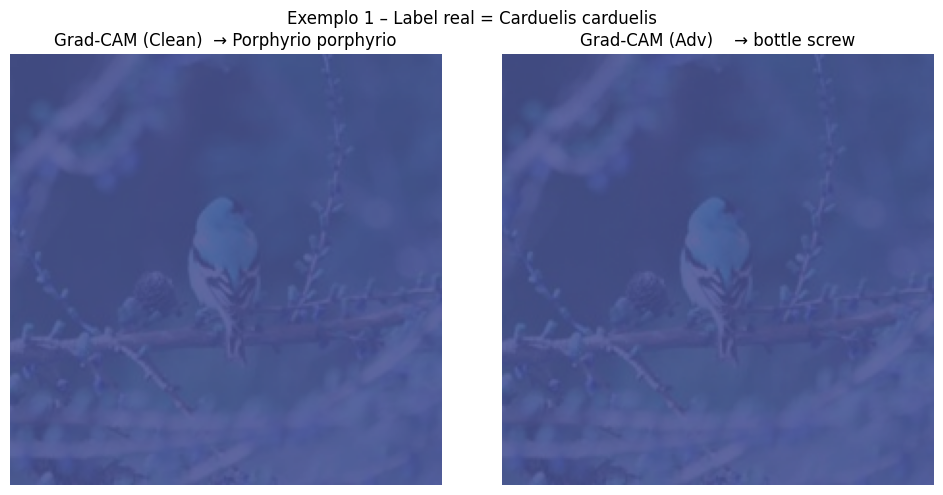

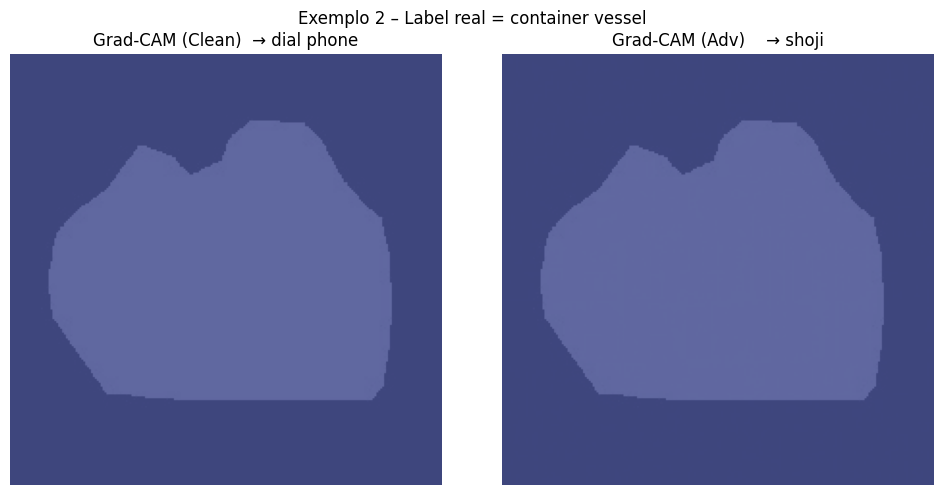

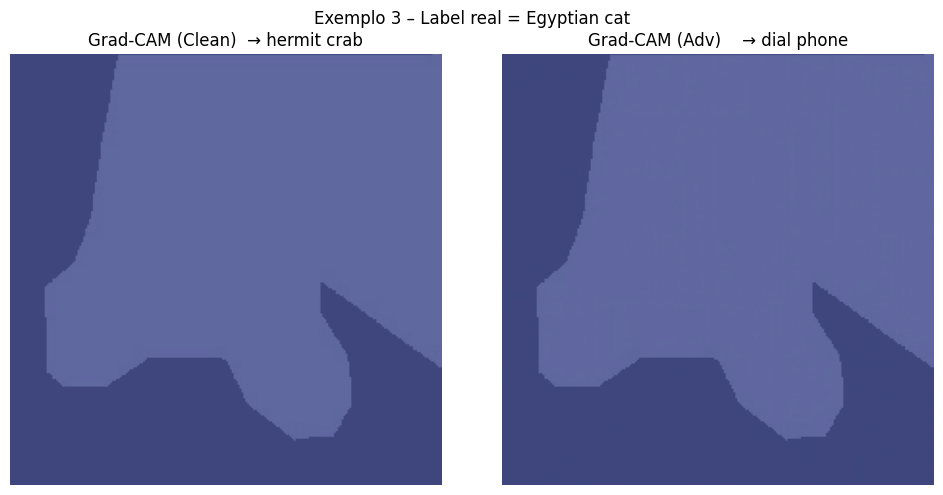

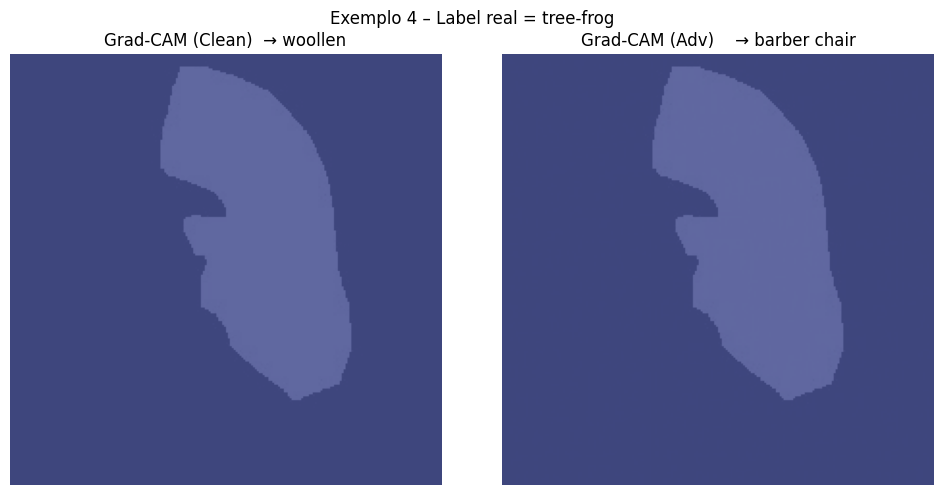

In [51]:
# Para CLIP-ViT:
show_gradcam_comparison(
    model      = clip_model,
    class_emb  = class_emb_clip,
    classes    = idx_to_name,
    test_loader= test_loader,
    n          = 4,
    epsilon    = 2/255,
    device     = "cuda"
)

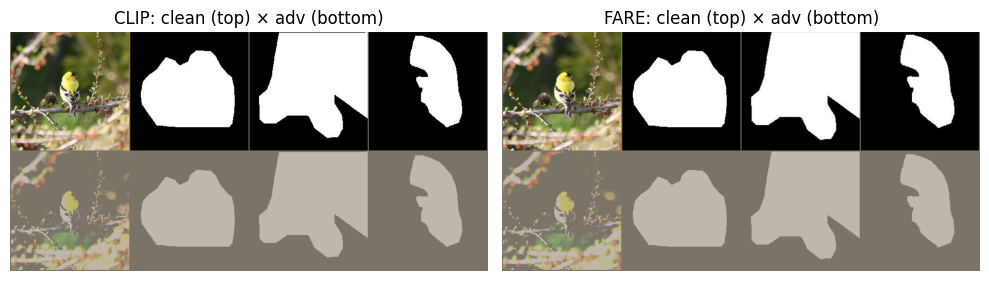

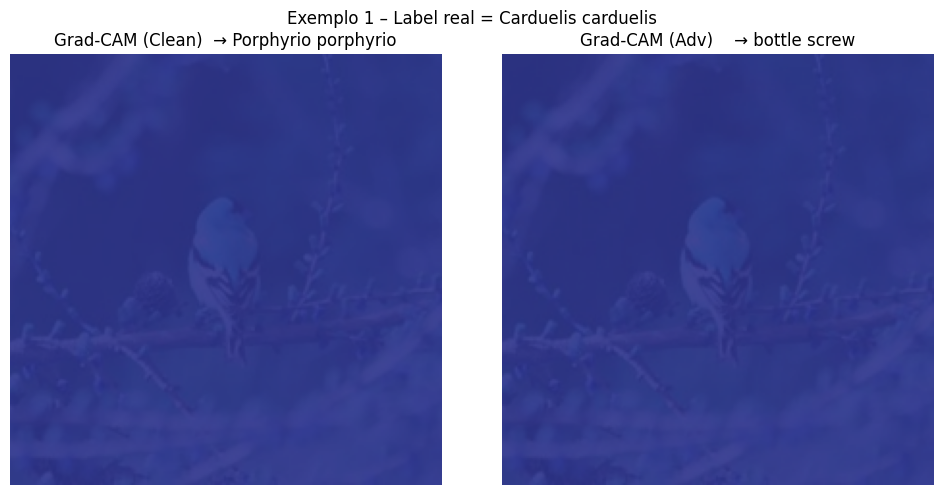

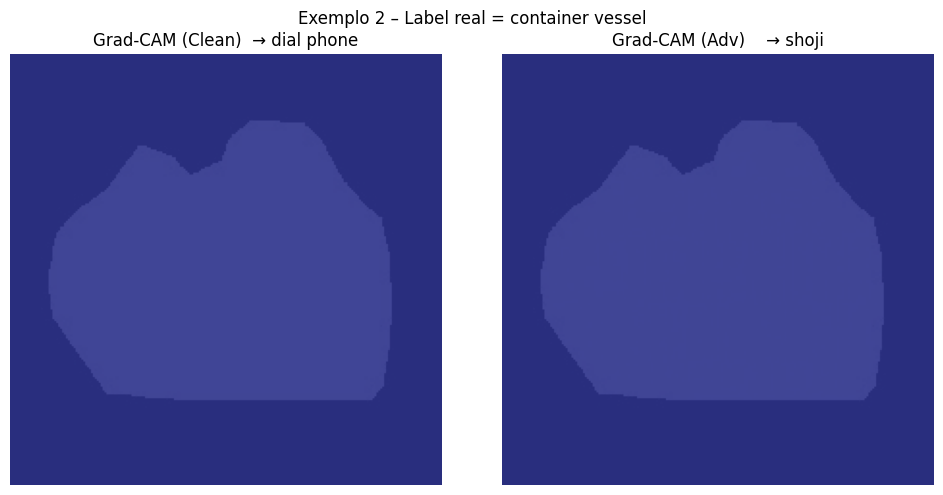

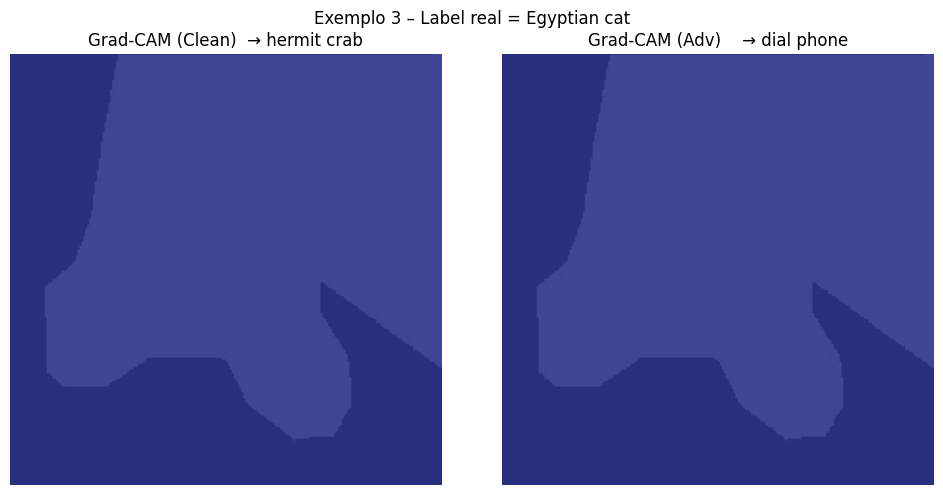

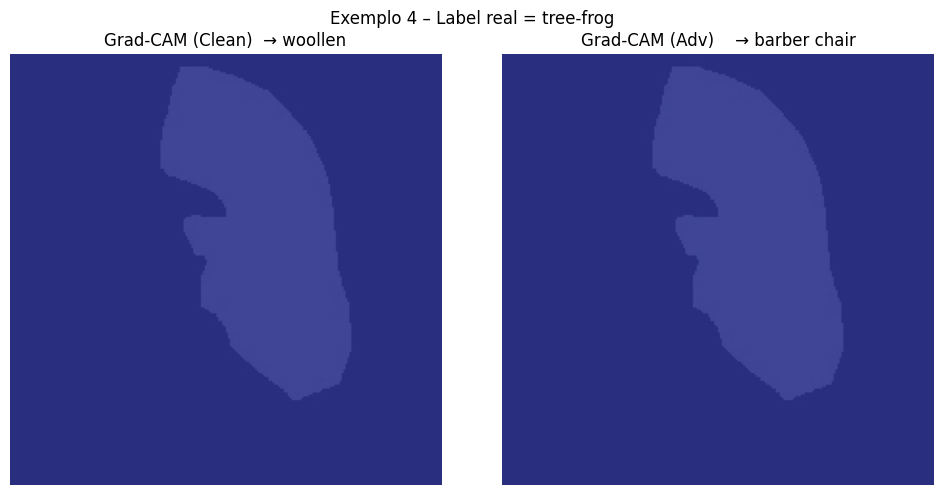

In [61]:
# 1) Grid clean × adv
show_examples(
    model_clean   = clip_model,
    model_robust  = fare_model,
    preprocess_clean = preprocess_clip,
    preprocess_robust= preprocess_fare,
    test_loader_clean = test_loader_clean,
    test_loader_robust = test_loader_robust,
    #test_loader      = test_loader,
    n=4, epsilon=2/255, device="cuda"
)

# 2) Grad-CAM overlay (funções que você já tem)
show_gradcam_comparison(
    model      = clip_model,         # repita depois com fare_model
    class_emb  = class_emb_clip,
    classes    = idx_to_name,
    test_loader= test_loader,
    n          = 4,
    epsilon    = 2/255,
    device     = "cuda"
)



In [64]:
import json

# caminho para o json com o mapeamento wnid → nome descritivo
wnid_json = "RIVAL10/meta/wnid_to_class.json"

# 1) carrega dicionário {wnid : "Nome da classe"}
with open(wnid_json, "r") as f:
    wnid_to_name = json.load(f)

# 2) carrega dicionário {wnid : índice} que você já usa no Dataset
with open("RIVAL10/meta/wnid_to_idx.json", "r") as f:
    wnid_to_idx = json.load(f)

# 3) converte para lista onde classes[i] devolve o nome
num_classes = len(wnid_to_idx)
classes = [""] * num_classes
for wnid, idx in wnid_to_idx.items():
    classes[idx] = wnid_to_name[wnid]

# agora 'classes' está definido:
print(classes[:5])       # conferência rápida

['Tinca tinca', 'Carassius auratus', 'Carcharodon carcharias', 'Galeocerdo cuvieri', 'hammerhead shark']


Encontrados   adv_ok = 0    adv_fail = 2
Nenhum exemplo adv_ok encontrado – ajuste epsilon ou percorra mais dados.


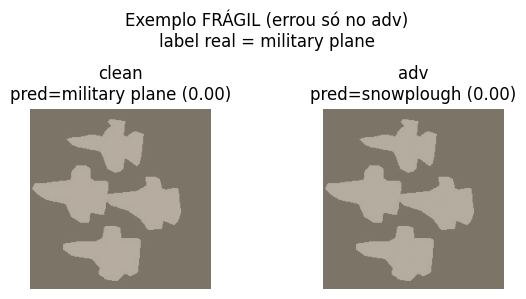

In [70]:
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

# ----------------------------------------------------------
# Configurações
device      = "cuda"
epsilon     = 2/255
wanted_ok   = 4   # quantos adv_ok você deseja
wanted_fail = 4   # quantos adv_fail você deseja
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(device)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(device)

# ----------------------------------------------------------
# Pequena função auxiliar: predição top-1 já normalizada
def predict_top1(model, imgs, class_emb):
    with torch.no_grad():
        emb = model.encode_image(imgs)            # (N,D)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        logits = emb @ class_emb.T                # (N,C)
        probs  = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
    return pred, conf      # ambos (N,)

# ----------------------------------------------------------
# Coleta exemplos
adv_ok, adv_fail = [], []   # cada item: (img_clean_norm, img_adv_norm, label, pred_clean, pred_adv, conf_clean, conf_adv)

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    adv    = fgsm_attack(model, images, epsilon=epsilon).to(device)

    pred_c, conf_c = predict_top1(model, images, class_emb)
    pred_a, conf_a = predict_top1(model, adv,    class_emb)

    for i in range(images.size(0)):
        ok_clean = pred_c[i] == labels[i]
        ok_adv   = pred_a[i] == labels[i]
        if ok_clean and ok_adv and len(adv_ok) < wanted_ok:
            adv_ok.append( (images[i].cpu(), adv[i].cpu(),
                            labels[i].cpu(), pred_c[i].cpu(), pred_a[i].cpu(),
                            conf_c[i].cpu(), conf_a[i].cpu()) )
        elif ok_clean and not ok_adv and len(adv_fail) < wanted_fail:
            adv_fail.append( (images[i].cpu(), adv[i].cpu(),
                              labels[i].cpu(), pred_c[i].cpu(), pred_a[i].cpu(),
                              conf_c[i].cpu(), conf_a[i].cpu()) )

    if len(adv_ok) >= wanted_ok and len(adv_fail) >= wanted_fail:
        break

print(f"Encontrados   adv_ok = {len(adv_ok)}    adv_fail = {len(adv_fail)}")

# ----------------------------------------------------------
# Função para desnormalizar e mostrar
def denorm(img):
    return torch.clamp(img * std.cpu() + mean.cpu(), 0, 1)

def show_pair(item, title):
    img_c,img_a,lab,p_c,p_a,cf_c,cf_a = item
    fig,axs = plt.subplots(1,2,figsize=(6,3))
    axs[0].imshow(to_pil_image(denorm(img_c)))
    axs[0].set_title(f"clean\npred={classes[p_c]} ({cf_c:.2f})")
    axs[0].axis("off")
    axs[1].imshow(to_pil_image(denorm(img_a)))
    axs[1].set_title(f"adv\npred={classes[p_a]} ({cf_a:.2f})")
    axs[1].axis("off")
    plt.suptitle(f"{title}\nlabel real = {classes[lab]}")
    plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Exibe um exemplo robusto e um adversarial-fail
if adv_ok:
    show_pair(adv_ok[0], "Exemplo ROBUSTO (acertou nos dois)")
else:
    print("Nenhum exemplo adv_ok encontrado – ajuste epsilon ou percorra mais dados.")

if adv_fail:
    show_pair(adv_fail[0], "Exemplo FRÁGIL (errou só no adv)")
else:
    print("Nenhum exemplo adv_fail encontrado – ajuste epsilon ou percorra mais dados.")
